# 🧪Lab: Predicting Seismic Building Response with Support Vector Regression

In this lab, you will practice **Support Vector Machine (SVM)** in the context of **regression**. Over the past two weeks, we have focused on SVM for **classification problems**. However, SVM can also be extended to handle **regression tasks**—this is known as **Support Vector Regression (SVR)**.

To explore this, you will work with the following paper:  https://www.nature.com/articles/s41598-024-81705-3

In this paper, the authors use **real seismic monitoring data** to develop an SVR-based model for predicting the **maximum inter-story drift ratio** of buildings during earthquakes. The authors compare a full-feature model with a reduced-feature version, and demonstrate that SVR is effective in this complex, real-world regression setting.

You will begin by reading the **introduction** of the paper to understand the motivation behind the problem. Later, you will apply Support Vector Regression to their dataset.

Reference:

- Tao, D., Fang, S., Liu, H. et al. Support vector regression model for the prediction of buildings’ maximum seismic response based on real monitoring data. Sci Rep 14, 29874 (2024). https://doi.org/10.1038/s41598-024-81705-3

--- 

**Software**: Use `scikit-learn` and its implementation of Support Vector Regression in this lab. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [59]:
#NAME(s) = ""

## 1. Paper reflection (10 points)

a. After reading the introduction of the paper, discuss within the group and address the following questions:
   
   - Why is predicting seismic building response important? (You may consider implications for human safety, economic losses, emergency planning, etc)
   It's important because it can allow us to predict and prepare for things caused by damage to buildings like property damage, casualties, and overall functional loss.  If we are able to predict these things then we can achieve close to real time emergency responses.

- Why might the dataset of this study be particularly well-suited for a machine learning approach? (You may think about the volume and diversity of data, the types of features provided, and the limitations of traditional physics-based methods).

It is well suited becuase it contains a lot of examples to train on (12,293 recordings, 147 different buildings, and 3,081 earthquakes), it includes varied structure types, and it has 41 input features. Its advantabes over physics-based methods are that it's faster (physics based methods are computationally intensive), and physics-based methods also need detailed and complete design information of a building to simulate it.

b. After reading the paper, explain, in your own words, how Support Vector Regression (SVR) works. In addition, explain Formulas (1) to (11) from the paper, specifically, what is the intuition behind each equation in light of what we covered in class regarding Support Vector Machine, so you can see the correspondence between SVM for classification and regression.

YOUR TEXT HERE

## 2. Exploratory Analysis (15 Points)

a. Load the dataset accompanying this lab and create a new dataset containing the same input features used as predictors in the paper, along with the target variable, *Drift*. **You will use only this new dataset throughout the remainder of the lab.** Display the first few rows of the resulting dataset.

*Hint*: The exact input features used in the predictive framework are clearly specified in the paper. You may also refer to Table 3 to help identify the corresponding features in the provided dataset.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# use the column names in row 2 and skip the units in row 3
data = pd.read_excel("data/data_lab02.xlsx", header=1, skiprows=[2])

# the predictors used in the paper
predictors = [
    "B_Lat.", "B_Long.", "Height", "No. of story", "F1", "F2", # building info
    "SA1", "SV1", "SD1", "SA2", "SV2", "SD2", # spectral measures
    "Avg_Sa", "Avg_Sv", "Avg_Sd",
    "Effective", "Bracketed 1 [0.05g]", "Uniform [0.05g]", # duration measures
    "Bracketed [0.1g]", "Uniform [0.1g]",
    "Bracketed [0.15g]", "Uniform [0.15g]",
    "Bracketed [0.2g]", "Uniform [0.2g]",
    "Significant_a1 [(5-75)%]", "Significant_a2 [(5-95)%]",
    "Significant_v1 [(5-75)%]", "Significant_v2 [(5-95)%]",
    "Significant_d1 [(5-75)%]", "Significant_d2 [(5-95)%]", "ZX",
    "E_Lat.", "E_Long.", "Magnitude", "Epicentral distance (R)", # earthquake info
    "PGA", "PGV", "PGD", "AI", "CAV", "DP",
]

# keep just these predictors and Drift for the rest of the lab
data = data[predictors + ["Drift"]].copy()
X = data.drop(columns="Drift")
y = data["Drift"]

print("Dataset shape:", data.shape)
print("Rows with missing predictors:", X.isna().any(axis=1).sum())
data.head()


Dataset shape: (12503, 42)
Rows with missing predictors: 587


,B_Lat.,B_Long.,Height,No. of story,F1,F2,SA1,SV1,SD1,SA2,...,E_Long.,Magnitude,Epicentral distance (R),PGA,PGV,PGD,AI,CAV,DP,Drift
0,36.132,140.073,3400.0,8,1.962438,1.596588,2.800003,0.245024,0.018094,2.064495,...,136.2283,5.3,420.7,1.577005,0.073452,0.009969,0.007308,14.943664,0.000081,-0.218343
1,36.132,140.073,3400.0,8,1.834042,1.684939,2.581543,0.259164,0.019248,2.205341,...,139.8917,3.8,16.6,3.449968,0.132411,0.013505,0.009687,10.468711,0.000050,-0.226958
2,36.132,140.073,3400.0,8,1.846080,1.696926,0.710809,0.083139,0.005131,0.671577,...,141.0583,4.2,132.2,0.854165,0.036735,0.003580,0.001478,4.989075,0.000010,-0.240754
3,36.132,140.073,3400.0,8,1.949488,1.580632,0.578160,0.053573,0.003708,0.366055,...,140.0867,3.4,9.8,0.549761,0.026009,0.002277,0.000338,2.158138,0.000001,-0.244348
4,36.132,140.073,3400.0,8,1.778042,1.144375,12.618900,0.986632,0.099006,22.317243,...,140.7517,5.7,96.6,5.863478,1.006804,0.193666,0.216008,79.905115,0.005511,-0.101461


In [61]:

# the predictors used in the paper
predictors = [
    "B_Lat.", "B_Long.", "Height", "No. of story", "F1", "F2", # building info
    "SA1", "SV1", "SD1", "SA2", "SV2", "SD2", # spectral measures
    "Avg_Sa", "Avg_Sv", "Avg_Sd",
    "Effective", "Bracketed 1 [0.05g]", "Uniform [0.05g]", # duration measures
    "Bracketed [0.1g]", "Uniform [0.1g]",
    "Bracketed [0.15g]", "Uniform [0.15g]",
    "Bracketed [0.2g]", "Uniform [0.2g]",
    "Significant_a1 [(5-75)%]", "Significant_a2 [(5-95)%]",
    "Significant_v1 [(5-75)%]", "Significant_v2 [(5-95)%]",
    "Significant_d1 [(5-75)%]", "Significant_d2 [(5-95)%]", "ZX",
    "E_Lat.", "E_Long.", "Magnitude", "Epicentral distance (R)", # earthquake info
    "PGA", "PGV", "PGD", "AI", "CAV", "DP",
]

# keep just these predictors and Drift for the rest of the lab
data = data[predictors + ["Drift"]].copy()
X = data.drop(columns="Drift")
y = data["Drift"]

print("Dataset shape:", data.shape)
print("Rows with missing predictors:", X.isna().any(axis=1).sum())
data.head()


Dataset shape: (12503, 42)
Rows with missing predictors: 587


,B_Lat.,B_Long.,Height,No. of story,F1,F2,SA1,SV1,SD1,SA2,...,E_Long.,Magnitude,Epicentral distance (R),PGA,PGV,PGD,AI,CAV,DP,Drift
0,36.132,140.073,3400.0,8,1.962438,1.596588,2.800003,0.245024,0.018094,2.064495,...,136.2283,5.3,420.7,1.577005,0.073452,0.009969,0.007308,14.943664,0.000081,-0.218343
1,36.132,140.073,3400.0,8,1.834042,1.684939,2.581543,0.259164,0.019248,2.205341,...,139.8917,3.8,16.6,3.449968,0.132411,0.013505,0.009687,10.468711,0.000050,-0.226958
2,36.132,140.073,3400.0,8,1.846080,1.696926,0.710809,0.083139,0.005131,0.671577,...,141.0583,4.2,132.2,0.854165,0.036735,0.003580,0.001478,4.989075,0.000010,-0.240754
3,36.132,140.073,3400.0,8,1.949488,1.580632,0.578160,0.053573,0.003708,0.366055,...,140.0867,3.4,9.8,0.549761,0.026009,0.002277,0.000338,2.158138,0.000001,-0.244348
4,36.132,140.073,3400.0,8,1.778042,1.144375,12.618900,0.986632,0.099006,22.317243,...,140.7517,5.7,96.6,5.863478,1.006804,0.193666,0.216008,79.905115,0.005511,-0.101461


b. Explore the distribution of the target variable (Drift), and create scatterplots between Drift and input features.

count    1.250300e+04
mean    -9.092765e-18
std      1.000040e+00
min     -2.528574e-01
25%     -2.242777e-01
50%     -1.835973e-01
75%     -5.777061e-02
max      4.153665e+01
Name: Drift, dtype: float64


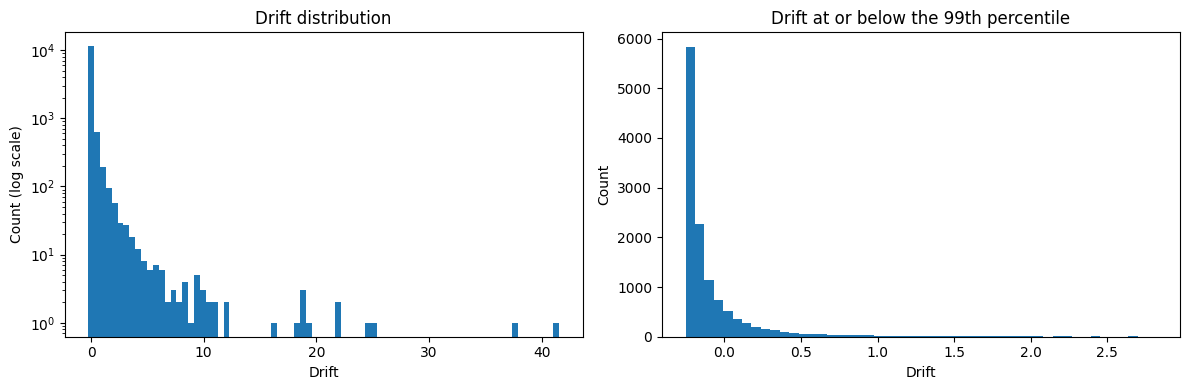

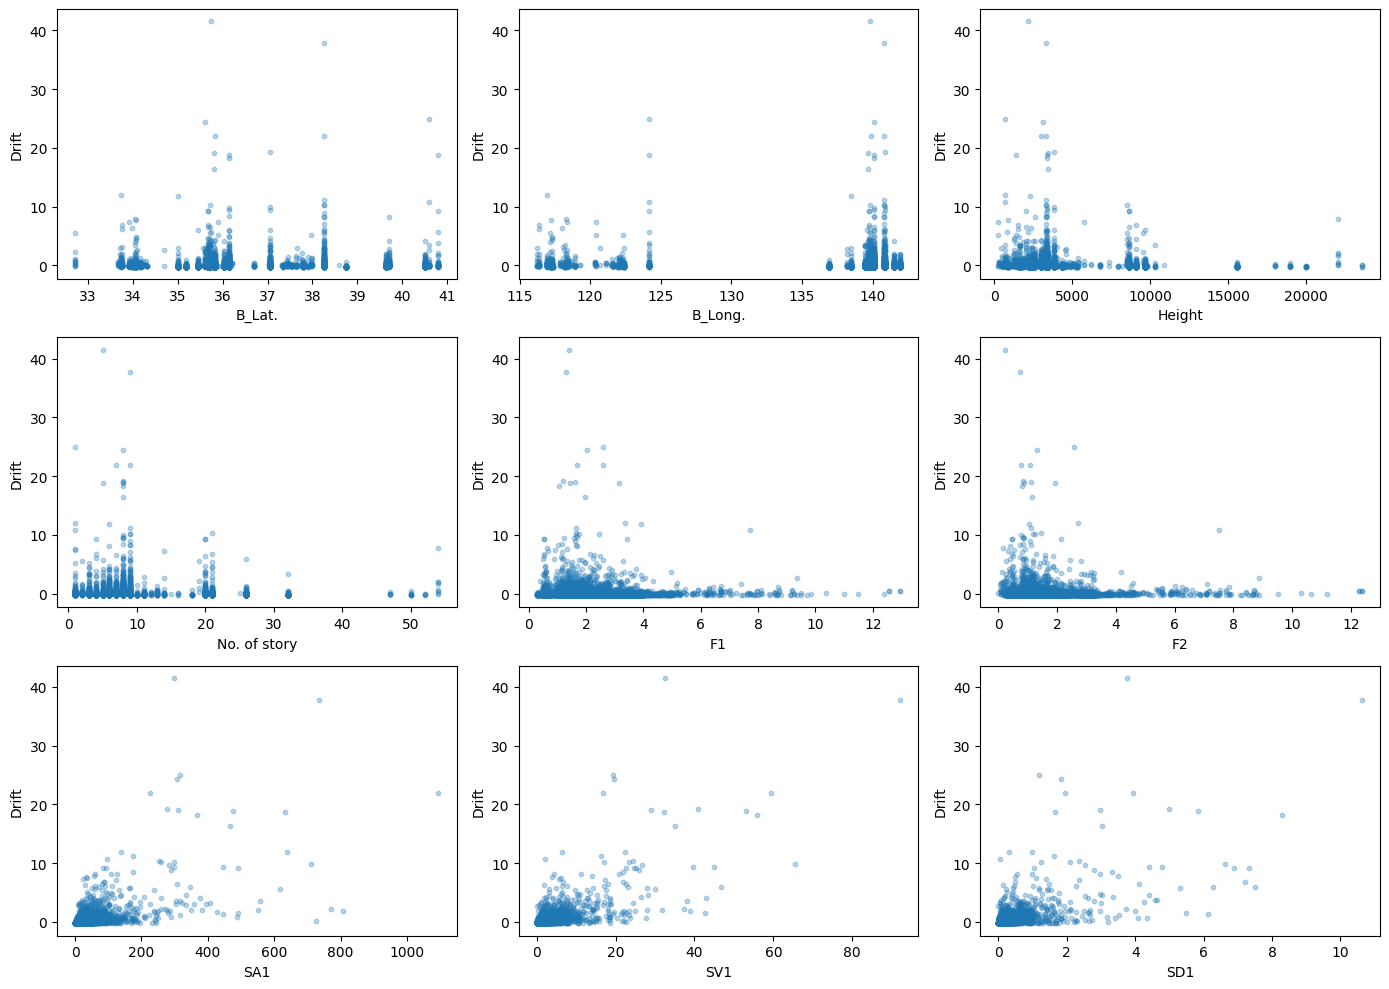

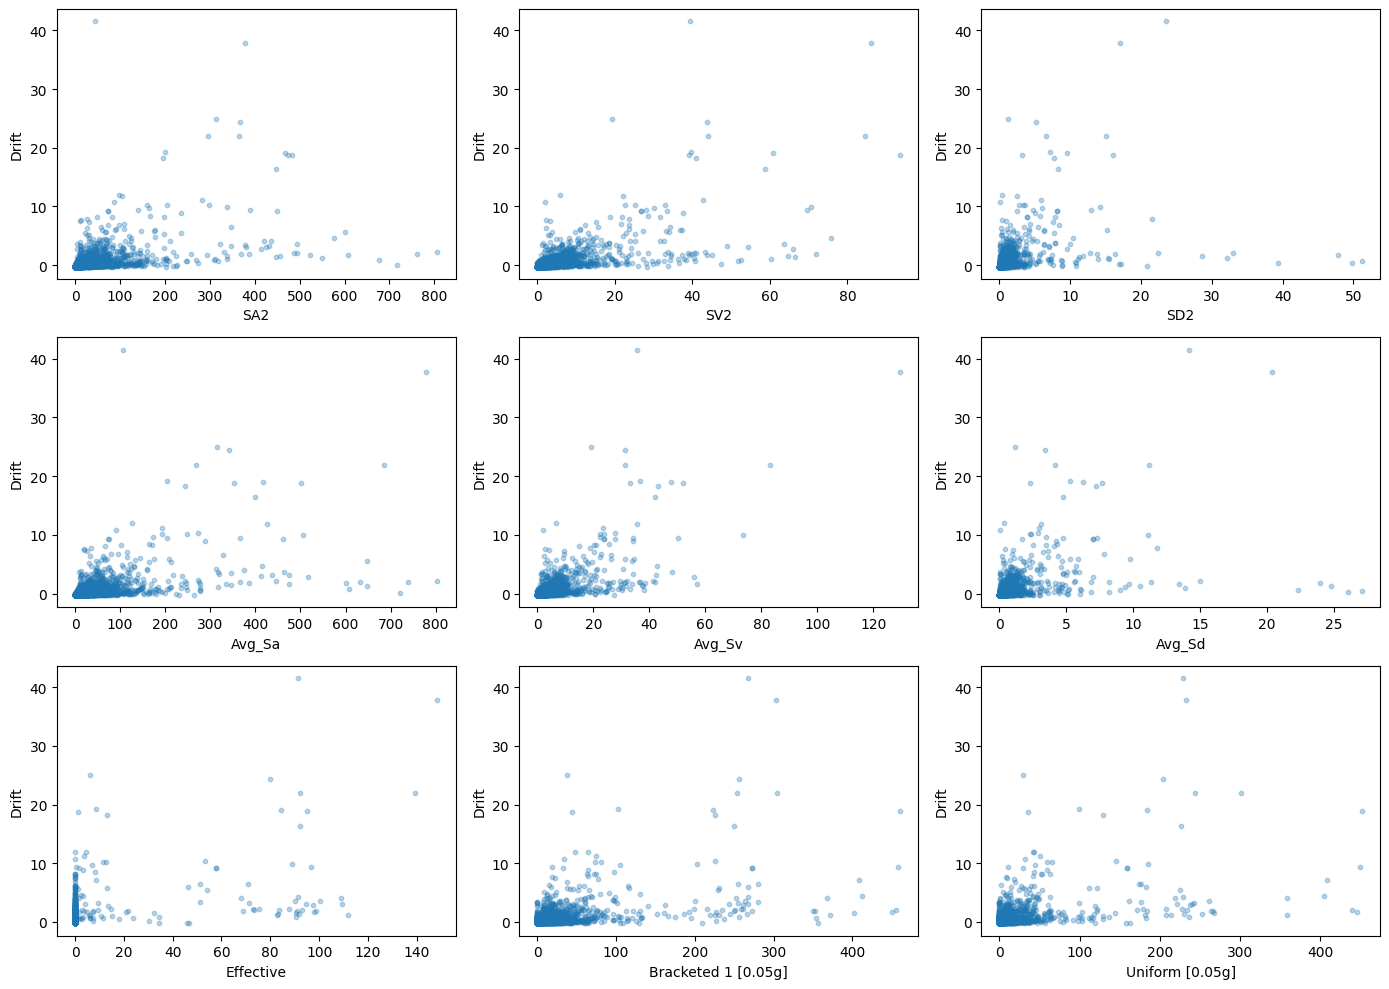

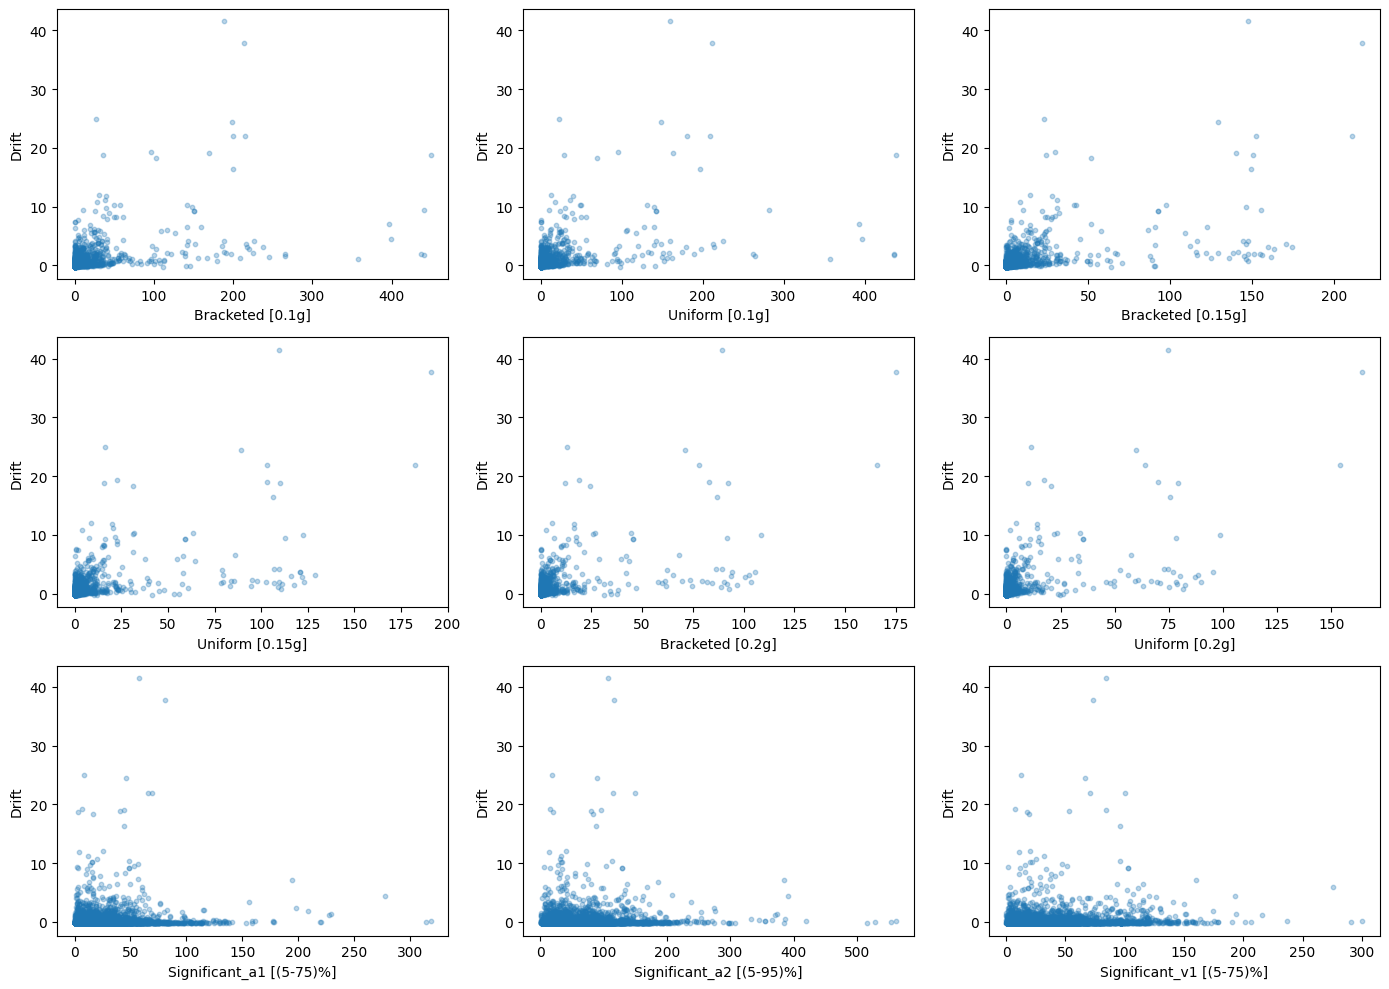

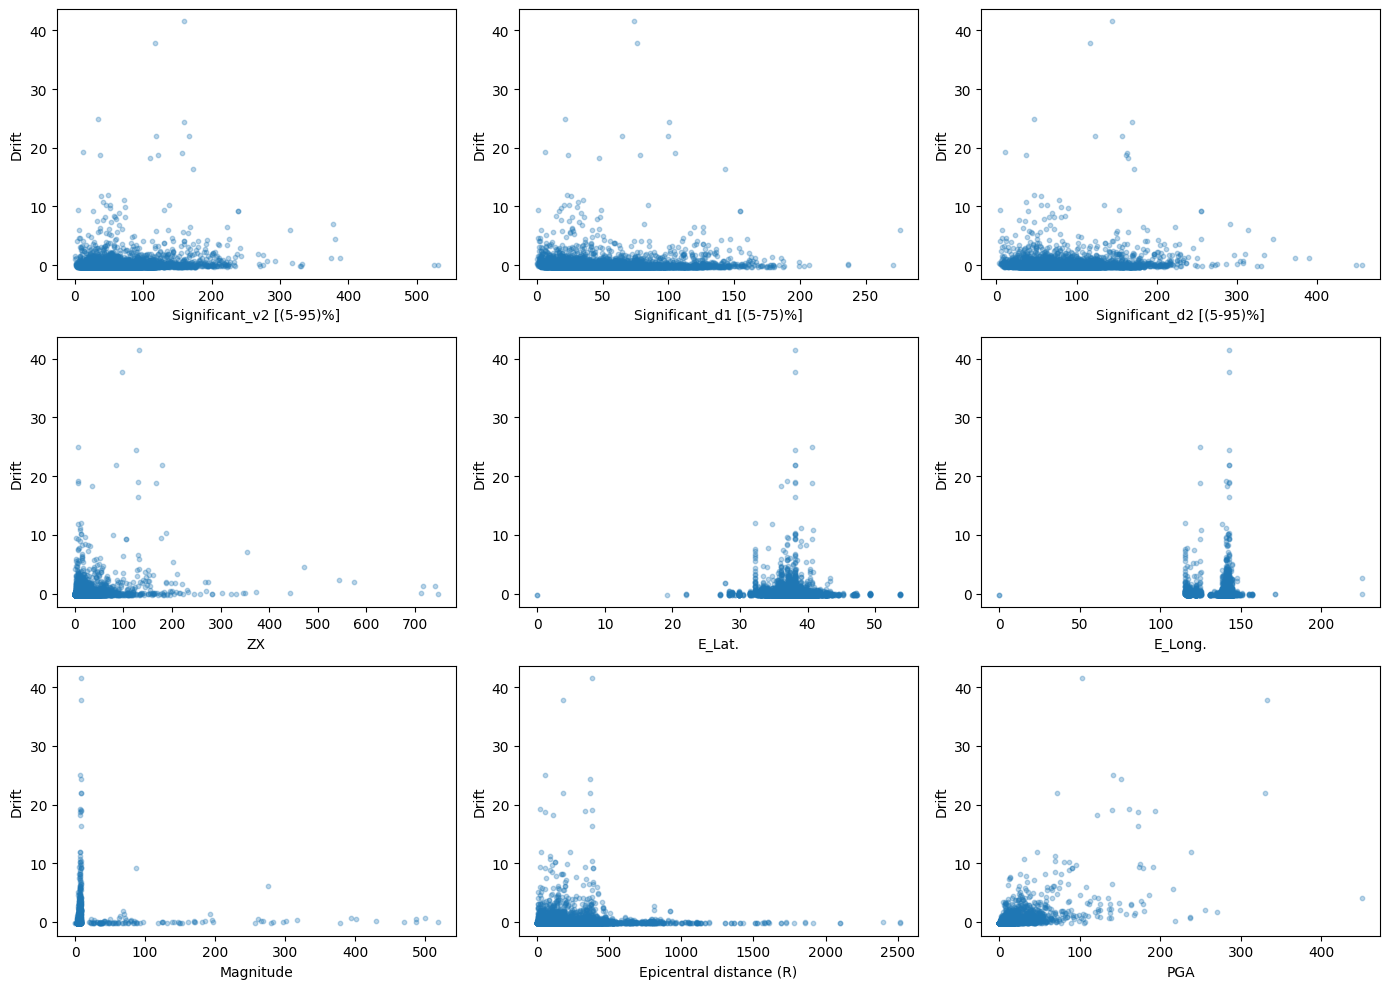

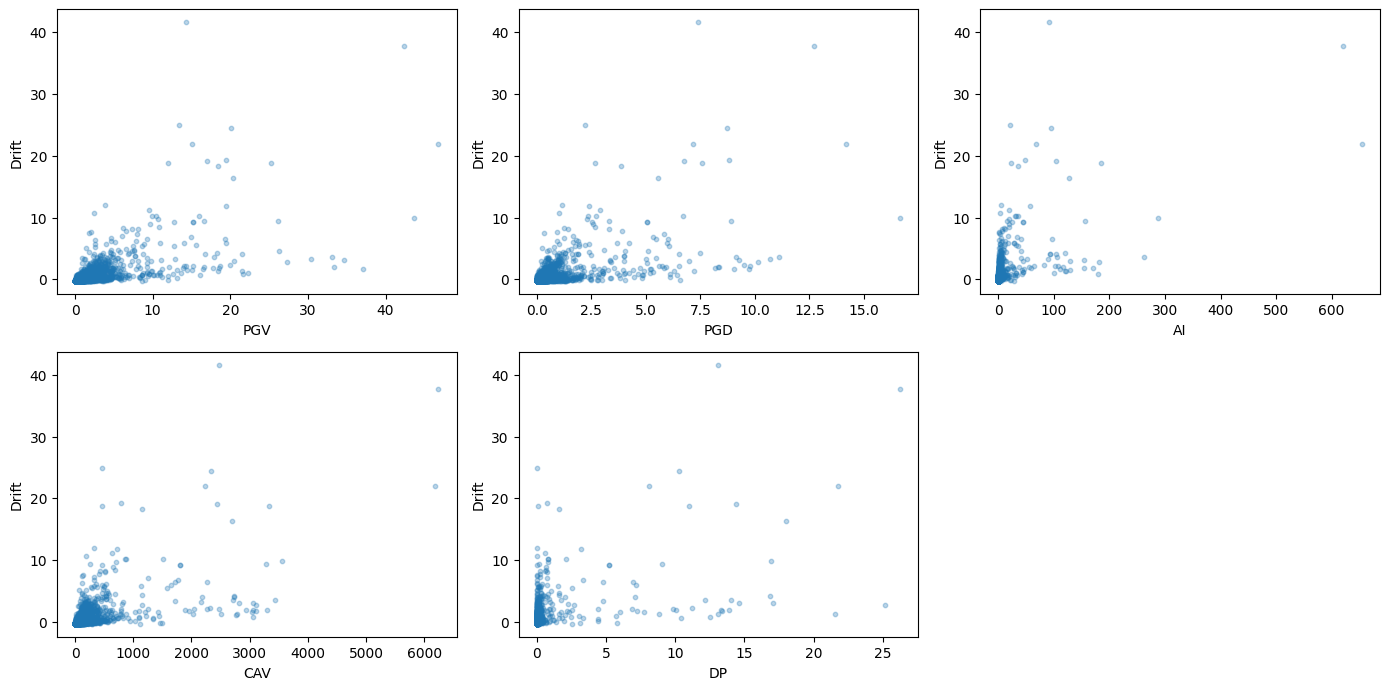

SV1                         0.721
Avg_Sv                      0.703
PGV                         0.664
SV2                         0.654
SD1                         0.648
CAV                         0.630
PGD                         0.625
SA1                         0.623
PGA                         0.599
Bracketed [0.2g]            0.591
Uniform [0.2g]              0.590
Uniform [0.15g]             0.589
Bracketed [0.15g]           0.588
Avg_Sa                      0.571
AI                          0.569
Bracketed 1 [0.05g]         0.548
Uniform [0.05g]             0.533
Bracketed [0.1g]            0.516
SA2                         0.515
DP                          0.515
Effective                   0.509
Uniform [0.1g]              0.508
Avg_Sd                      0.503
SD2                         0.415
ZX                          0.198
Significant_v2 [(5-95)%]    0.145
Significant_v1 [(5-75)%]    0.122
Significant_a1 [(5-75)%]    0.100
Significant_a2 [(5-95)%]    0.098
B_Long.       

In [62]:
print(y.describe())

# show the full distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(y, bins=80)
plt.yscale("log") # log scale so we can see small vals better
plt.xlabel("Drift")
plt.ylabel("Count (log scale)")
plt.title("Drift distribution")

plt.subplot(1, 2, 2)
plt.hist(y[y <= y.quantile(0.99)], bins=50) #now lets look at the distribution of the lower 99% of vals so we can see majority dist.
plt.xlabel("Drift")
plt.ylabel("Count")
plt.title("Drift at or below the 99th percentile")
plt.tight_layout()
plt.show()

# plot each predictor against drift, 9 plots at a time
for start in range(0, len(predictors), 9):
    plt.figure(figsize=(14, 10))
    for i, feature in enumerate(predictors[start:start + 9]):
        plt.subplot(3, 3, i + 1)
        plt.scatter(X[feature], y, alpha=0.3, s=10)
        plt.xlabel(feature)
        plt.ylabel("Drift")
    plt.tight_layout()
    plt.show()

# check which features have the strongest correlations with drift
correlations = X.corrwith(y)
correlations = correlations.sort_values(key=abs, ascending=False)
correlations.round(3)


c. Highlight any particular pattern you observe from the visualizations. Which input features seem potentially more influential in predicting Drift?

Drift is very right skewed.  Most of the observations are on the low end, with a median of about -0.184, while a couple large values go all the way up to 41.54.  The mean is about 0 and the sd is about one, so drift may have already been standardized.

The most obvious positive associations are SV1 and PGV.  SV1 has the largest correlation with drift, about 0.721.  The next largest are Avg_Sv at 0.703, PGV at 0.664, SV2 at 0.654, and SD1 at 0.648.  The magnitude plot is interesting because it goes above 500, which is not reasonable for Mw units (it shows mw in the dropped row). The dataset also has 587 rows missing at least one input feature, which will need to be handled before fitting a model.

## 3. Fit and evaluate (30 points)

a. Fit and evaluate a predictive framework using an SVR model. The process should include automatic tuning of both the kernel and the penalty parameter ((C)). Tune the hyperparameters using cross-validation on the training set, and evaluate the final predictive framework on a separate reporting set. Evaluate its performance using at least the Coefficient of Determination ($R^2$) and Mean Squared Error (MSE).

*N.B.* Remember that a predictive framework may involve more than just the predictive algorithm itself. Consider whether the characteristics of the predictors require any additional steps before fitting the model.

In [63]:
# [Your code here]

b. Repeat the previous process using an Ridge regression predictive framework. Be sure to include automatic tuning of the model's hyperparameters, specifically, `alpha`.

In [64]:
# [Your code here]

c. Use predicted vs. true value scatterplots to compare the SVR and Ridge predictive frameworks. Embed performance metrics (e.g., R², MSE) in each plot.

Which predictive framework appears to perform better at this task?

In [65]:
# [Your code here]

## 4. Reduced SVR Model (30 points)

a. Add a feature selection step to the SVR predictive framework that selects the 10 features most highly correlated with Drift. Retrain  this updated framework and evaluate its performance.

In [66]:
# [Your code here]

Subsequently, answer the following questions:

- How much does the performance change?
- What are the practical advantages of using this predictive framework with a smaller subset of features?

Elaborate on your answers.

b. Compare the performance of this reduced-feature SVR framework with an optimal Lasso regression framework that uses all available features.

- Do both frameworks select the same features?
- How do their performances compare?

In [67]:
# [Your code here]

## 5: Robustness to Point Removal (10 points)

a. Compare the sensitivity of SVR and Ridge Regression predictive frameworks to small changes in the training set. To achieve this, randomly remove 10 training points, retrain both predictive frameworks, and assess how much the predictions change.

- Which predictive frameworks appears more stable?
- Why?

In [68]:
# [Your code here]

## 6. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE